# **<font color="red">With Memory Chatbot</font>**

In [1]:
import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

# =========================
# 1. Initialize LLMs
# =========================

## Conversational LLM
chat_llm = ChatOllama(
    model="llama3.2:3b",
    temperature=0.5,
)

## LTM Store (START EMPTY)
store = InMemoryStore()

## Use NON-reasoning model for memory extraction
memory_llm = ChatOllama(
    model="qwen3:1.7b",
    temperature=0.5
)


In [2]:
# =========================
# 2. System Prompt
# =========================
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize your responses based
on what you know about the user.

Your goal is to provide relevant, friendly, and tailored assistance that reflects the
user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, always personalize your response by:
    - Always Address the user by name (e.g., "Sure, Vikas...") when appropriate
    - Referencing known projects, tools, or preferences (e.g., "Your MCP server python based project")
    - Adjusting the tone to feel friendly, natural, and directly aimed at the user.
Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    - Greetings and transitions
    - Help or guidance tailored to tools and frameworks the user uses.
    - Follow-up messages that continue from past context
Always ensure that personalization is based only on know user details and not assumed.
In the end suggest 3 relevant further questions based on the current response and user profile
The user's memory (which may be empty) is provided as: {user_details_content}
"""

In [3]:
# =========================
# 3. Pydantic Models
# =========================
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory")
    is_new: bool = Field(description="True if new, False if duplicate")

class MemoryDecision(BaseModel):
    should_write: bool
    memories: List[MemoryItem] = Field(default_factory=list)

memory_extractor = memory_llm.with_structured_output(MemoryDecision)


In [4]:
# =========================
# 4. Memory Prompt
# =========================
MEMORY_PROMPT = """You are responsible for updating and maintining accurate user memory.
CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, se is_new=True ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=False.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=False and an empty list.
"""


In [5]:
# =========================
# 5. Node 1: Remember
# =========================
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    # Existing Memory
    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg}
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns, str(uuid.uuid4()), {"data": mem.text})
    return {} # no message change



In [6]:
# =========================
# 6. Node 2: Chat
# =========================
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}


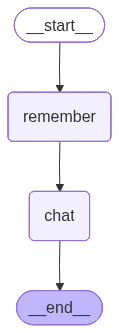

In [7]:
# =========================
# 7. Graph
# =========================
builder = StateGraph(MessagesState)

## Nodes
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

## Edge
builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [8]:
# =========================
# 8. Demo
# =========================
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Vikas"}]}, config)
print(result["messages"][-1].content)
print("\n")

## Check Memory
print("-"*20 + "Chat Memory" + "-"*20)
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])
print("-"*50)


Hello Vikas! It's great to meet you. I'm here to help with any questions or concerns you might have. How can I assist you today? Is there something specific on your mind that you'd like to chat about or get help with?

(By the way, I don't have any information stored in our previous conversation since this is the start of our interaction.)


--------------------Chat Memory--------------------
User's name is Vikas.
--------------------------------------------------


In [9]:
result = graph.invoke({"messages": [{"role": "user", "content": "I am a AI Engineer in Lagozon Technology"}]}, config)
print(result["messages"][-1].content)
print("\n")

## Check Memory
print("-"*20 + "Chat Memory" + "-"*20)
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])
print("-"*50)

Hi Vikas, 

It's great to see you again! As an AI Engineer at Lagozon Technology, I'd like to help you with any questions or challenges you're facing. What can I assist you with today? Are you working on a new project, or do you need help troubleshooting something?

If you're feeling stuck or would like some guidance, I'm here to provide relevant and helpful responses based on your expertise in AI engineering.

Here are three potential areas of discussion:

1. **Deep dive into a specific technology**: Would you like me to explain a particular AI-related concept, framework, or tool that you use frequently?
2. **Project assistance**: Are you working on a new project, and would you like some help with planning, architecture, or implementation?
3. **Collaboration ideas**: Are there any opportunities for collaboration or knowledge-sharing within the Lagozon Technology team or with other AI engineers?

Which direction would you like to explore first?


--------------------Chat Memory--------

In [10]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result["messages"][-1].content)
print("\n")

## Check Memory
print("-"*20 + "Chat Memory" + "-"*20)
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])
print("-"*50)


Hi Vikas,

I'd be happy to explain Generative Artificial Intelligence (GenAI) in simple terms. As an AI engineer, you're likely familiar with the concept, but I'll provide a brief overview nonetheless.

**What is GenAI?**

Generative Artificial Intelligence refers to a subset of machine learning models that can generate new, original data that resembles existing patterns or structures. Think of it like a digital artist who can create new paintings based on the style and techniques learned from famous artists.

**Types of GenAI:**

There are several types of GenAI models, including:

1. **Text Generation**: Generating text similar to human-written content, such as articles, chatbot responses, or even entire books.
2. **Image Synthesis**: Creating new images that resemble existing ones, like generating realistic faces or landscapes.
3. **Audio Generation**: Producing new audio files that mimic real-world sounds or music.

**How does GenAI work?**

GenAI models use complex algorithms to a